In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

accel = pd.read_csv(r"D:\PROJECTS\YAANENDRIYA\data\raw\acceleration_Allan.csv", header=None, names=['time', 'x', 'y', 'z'])

dt = accel['time'].diff().mean()  # Calculate the average time difference between samples
sampling_frequency = 1 / dt  # Calculate the sampling frequency
print(f"Sampling Frequency: {sampling_frequency:.3f} Hz")

Sampling Frequency: 201.333 Hz


In [8]:
tau = 1  # Time interval for Allan deviation calculation
m = int(tau * sampling_frequency)  # Number of samples in the time interval
print(f"Number of samples in {tau} second(s): {m}")

Number of samples in 1 second(s): 201


In [15]:
z = accel['z'].to_numpy()  # Convert the z-axis acceleration data to a NumPy array
z_block_1 = z[:m]
print(len(z_block_1))
print(z_block_1[:10])
z_mean_1 = np.mean(z_block_1)
print(f"Mean of the first {m} samples: {z_mean_1:.3f}")

201
[9.86272 9.84438 9.79668 9.81556 9.81587 9.797   9.82593 9.80639 9.82067
 9.81106]
Mean of the first 201 samples: 9.806


In [16]:
z_block_2 = z[m:2*m]
print(len(z_block_2))
print(z_block_2[:10])
z_mean_2 = np.mean(z_block_2)
print(f"Mean of the next {m} samples: {z_mean_2:.3f}")

201
[9.77777 9.79683 9.82503 9.80147 9.80612 9.82522 9.821   9.77775 9.79691
 9.74961]
Mean of the next 201 samples: 9.807


In [17]:
print(f"Mean of the first {m} samples: {z_mean_1:.3f}")
print(f"Mean of the next {m} samples: {z_mean_2:.3f}")
print(f"Difference between means: {abs(z_mean_1 - z_mean_2):.3f}")

Mean of the first 201 samples: 9.806
Mean of the next 201 samples: 9.807
Difference between means: 0.001


In [22]:
k = len(z) // m  # Number of complete blocks of size m
print(f"Number of complete blocks of size {m}: {k}")
remainder = len(z) % m
print(f"Number of remaining samples after {k} complete blocks: {remainder}")

Number of complete blocks of size 201: 53053
Number of remaining samples after 53053 complete blocks: 176


In [23]:
usable_samples = k * m
z_complete = z[:usable_samples]

z_blocks = z_complete.reshape(k, m)

block_means = z_blocks.mean(axis=1)

print("Usable samples:", len(z_complete))
print("Block shape:", z_blocks.shape)
print("Number of block means:", len(block_means))
print("First 5 block means:", block_means[:5])

Usable samples: 10663653
Block shape: (53053, 201)
Number of block means: 53053
First 5 block means: [9.8060804  9.8066507  9.80788876 9.80739224 9.80858159]


In [24]:
differences = np.diff(block_means)

squared_differences = differences ** 2

allan_variance = squared_differences.mean() / 2

allan_deviation = np.sqrt(allan_variance)

print(f"Allan variance: {allan_variance}")
print(f"Allan deviation: {allan_deviation}")

Allan variance: 3.310143648240208e-06
Allan deviation: 0.0018193800175444954


In [25]:
def calculate_allan_deviation(signal, sampling_frequency, tau):

    signal = np.asarray(signal)

    # Number of samples in one averaging interval
    m = int(tau * sampling_frequency)

    if m < 1:
        raise ValueError("Tau is too small for the sampling frequency.")

    # Number of complete blocks
    k = len(signal) // m

    if k < 2:
        raise ValueError("Not enough data for this tau.")

    # Keep only complete blocks
    usable_samples = k * m
    signal_complete = signal[:usable_samples]

    # Divide into blocks
    blocks = signal_complete.reshape(k, m)

    # Average each block
    block_means = blocks.mean(axis=1)

    # Difference between consecutive block means
    differences = np.diff(block_means)

    # Allan variance
    allan_variance = np.mean(differences ** 2) / 2

    # Allan deviation
    allan_deviation = np.sqrt(allan_variance)

    # Actual averaging time
    actual_tau = m / sampling_frequency

    return actual_tau, allan_deviation

In [26]:
tau = 1

actual_tau_z, adev_z = calculate_allan_deviation(
    accel['z'],
    sampling_frequency,
    tau
)

print(f"Actual tau: {actual_tau_z:.6f} s")
print(f"Allan deviation: {adev_z:.9f} m/s²")

Actual tau: 0.998344 s
Allan deviation: 0.001819380 m/s²


In [27]:
tau_values = np.logspace(
    np.log10(0.01),
    np.log10(1000),
    30
)

print(tau_values)

[1.00000000e-02 1.48735211e-02 2.21221629e-02 3.29034456e-02
 4.89390092e-02 7.27895384e-02 1.08263673e-01 1.61026203e-01
 2.39502662e-01 3.56224789e-01 5.29831691e-01 7.88046282e-01
 1.17210230e+00 1.74332882e+00 2.59294380e+00 3.85662042e+00
 5.73615251e+00 8.53167852e+00 1.26896100e+01 1.88739182e+01
 2.80721620e+01 4.17531894e+01 6.21016942e+01 9.23670857e+01
 1.37382380e+02 2.04335972e+02 3.03919538e+02 4.52035366e+02
 6.72335754e+02 1.00000000e+03]


In [28]:
tau_z = []
adev_z = []

for tau in tau_values:

    actual_tau, adev = calculate_allan_deviation(
        accel['z'],
        sampling_frequency,
        tau
    )

    tau_z.append(actual_tau)
    adev_z.append(adev)
tau_z = np.array(tau_z)
adev_z = np.array(adev_z)
print(tau_z)
print(adev_z)

[9.93376727e-03 9.93376727e-03 1.98675345e-02 2.98013018e-02
 4.47019527e-02 6.95363709e-02 1.04304556e-01 1.58940276e-01
 2.38410414e-01 3.52648738e-01 5.26489665e-01 7.84767614e-01
 1.16721765e+00 1.73840927e+00 2.59271326e+00 3.85430170e+00
 5.73178371e+00 8.52813920e+00 1.26854208e+01 1.88691909e+01
 2.80678594e+01 4.17516238e+01 6.21009461e+01 9.23641681e+01
 1.37379034e+02 2.04332626e+02 3.03918643e+02 4.52031113e+02
 6.72332269e+02 9.99997583e+02]
[0.01794738 0.01794738 0.01269437 0.0103658  0.00846225 0.00679472
 0.00554746 0.0044996  0.00367667 0.00303697 0.00248285 0.00204197
 0.00167829 0.00139725 0.00114382 0.00096342 0.00080903 0.00070179
 0.00062111 0.00056243 0.00061287 0.00062678 0.0006231  0.00073022
 0.00081162 0.00097953 0.00138282 0.00185101 0.00196793 0.00287779]


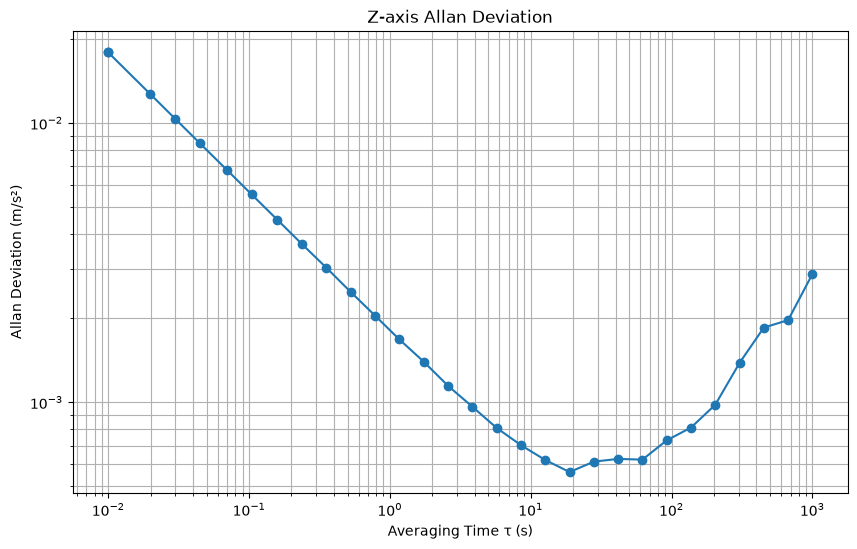

In [29]:
plt.figure(figsize=(10, 6))

plt.loglog(tau_z, adev_z, marker='o')

plt.xlabel('Averaging Time τ (s)')
plt.ylabel('Allan Deviation (m/s²)')
plt.title('Z-axis Allan Deviation')
plt.grid(True, which='both')
plt.show()

In [34]:
tau_x = []
adev_x = []

for tau in tau_values:

    actual_tau, adev = calculate_allan_deviation(
        accel['x'],
        sampling_frequency,
        tau
    )

    tau_x.append(actual_tau)
    adev_x.append(adev)

tau_x = np.array(tau_x)
adev_x = np.array(adev_x)
print(tau_x)
print(adev_x)

[9.93376727e-03 9.93376727e-03 1.98675345e-02 2.98013018e-02
 4.47019527e-02 6.95363709e-02 1.04304556e-01 1.58940276e-01
 2.38410414e-01 3.52648738e-01 5.26489665e-01 7.84767614e-01
 1.16721765e+00 1.73840927e+00 2.59271326e+00 3.85430170e+00
 5.73178371e+00 8.52813920e+00 1.26854208e+01 1.88691909e+01
 2.80678594e+01 4.17516238e+01 6.21009461e+01 9.23641681e+01
 1.37379034e+02 2.04332626e+02 3.03918643e+02 4.52031113e+02
 6.72332269e+02 9.99997583e+02]
[0.0181916  0.0181916  0.01287001 0.01051747 0.00858885 0.00689208
 0.00563501 0.00458349 0.00374689 0.00308519 0.00253144 0.00208772
 0.00172483 0.00143159 0.00120548 0.00100995 0.00085881 0.00073933
 0.00064244 0.00058388 0.00055143 0.00049875 0.00049619 0.00048818
 0.00051154 0.00057167 0.00056982 0.00065911 0.00066938 0.00071191]


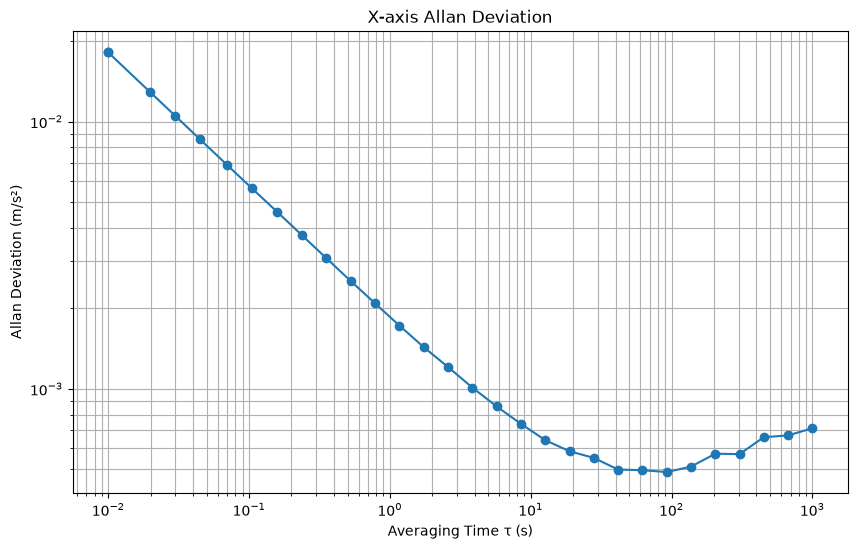

In [31]:
plt.figure(figsize=(10, 6))

plt.loglog(tau_x, adev_x, marker='o')

plt.xlabel('Averaging Time τ (s)')
plt.ylabel('Allan Deviation (m/s²)')
plt.title('X-axis Allan Deviation')
plt.grid(True, which='both')
plt.show()

In [32]:
tau_y = []
adev_y = []

for tau in tau_values:

    actual_tau, adev = calculate_allan_deviation(
        accel['y'],
        sampling_frequency,
        tau
    )

    tau_y.append(actual_tau)
    adev_y.append(adev)

tau_y = np.array(tau_y)
adev_y = np.array(adev_y)

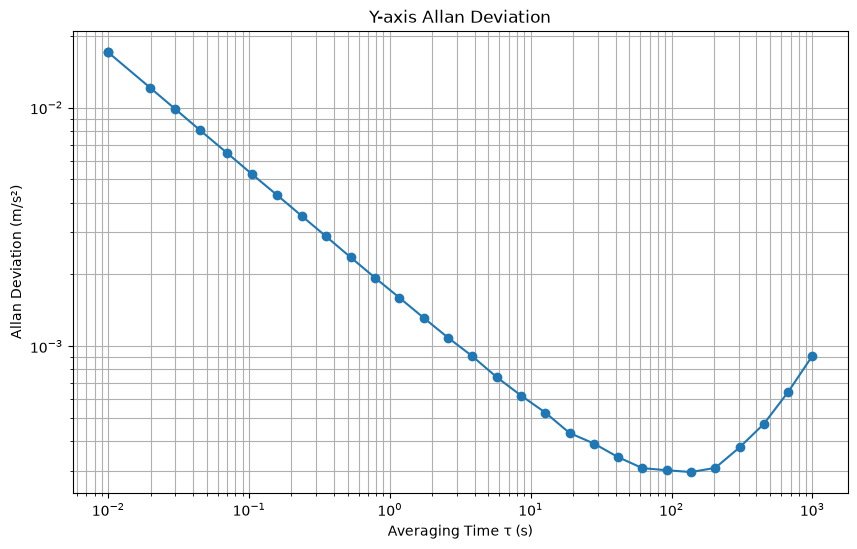

In [33]:
plt.figure(figsize=(10, 6))

plt.loglog(tau_y, adev_y, marker='o')

plt.xlabel('Averaging Time τ (s)')
plt.ylabel('Allan Deviation (m/s²)')
plt.title('Y-axis Allan Deviation')
plt.grid(True, which='both')
plt.show()

In [35]:
axes = {
    'X': (tau_x, adev_x),
    'Y': (tau_y, adev_y),
    'Z': (tau_z, adev_z)
}

for axis, (tau, adev) in axes.items():

    min_index = np.argmin(adev)

    print(f"{axis}-axis")
    print(f"Minimum ADEV: {adev[min_index]:.9f} m/s²")
    print(f"At tau: {tau[min_index]:.3f} s")
    print()

X-axis
Minimum ADEV: 0.000488184 m/s²
At tau: 92.364 s

Y-axis
Minimum ADEV: 0.000296823 m/s²
At tau: 137.379 s

Z-axis
Minimum ADEV: 0.000562429 m/s²
At tau: 18.869 s



In [ ]:
print("X:")
for t, a in zip(tau_x, adev_x):
    print(f"{t:.3f} s -> {a:.6e}")

X:
0.010 s -> 1.819160e-02
0.010 s -> 1.819160e-02
0.020 s -> 1.287001e-02
0.030 s -> 1.051747e-02
0.045 s -> 8.588846e-03
0.070 s -> 6.892079e-03
0.104 s -> 5.635011e-03
0.159 s -> 4.583485e-03
0.238 s -> 3.746892e-03
0.353 s -> 3.085194e-03
0.526 s -> 2.531436e-03
0.785 s -> 2.087719e-03
1.167 s -> 1.724826e-03
1.738 s -> 1.431593e-03
2.593 s -> 1.205485e-03
3.854 s -> 1.009949e-03
5.732 s -> 8.588109e-04
8.528 s -> 7.393328e-04
12.685 s -> 6.424370e-04
18.869 s -> 5.838797e-04
28.068 s -> 5.514271e-04
41.752 s -> 4.987531e-04
62.101 s -> 4.961904e-04
92.364 s -> 4.881838e-04
137.379 s -> 5.115377e-04
204.333 s -> 5.716661e-04
303.919 s -> 5.698158e-04
452.031 s -> 6.591121e-04
672.332 s -> 6.693849e-04
999.998 s -> 7.119106e-04
Y:
0.010 s -> 1.709648e-02
0.010 s -> 1.709648e-02
0.020 s -> 1.210575e-02
0.030 s -> 9.878851e-03
0.045 s -> 8.054931e-03
0.070 s -> 6.465485e-03
0.104 s -> 5.275278e-03
0.159 s -> 4.286903e-03
0.238 s -> 3.502053e-03
0.353 s -> 2.882941e-03
0.526 s -> 2.357

In [38]:
print("Y:")
for t, a in zip(tau_y, adev_y):
    print(f"{t:.3f} s -> {a:.6e}")

Y:
0.010 s -> 1.709648e-02
0.010 s -> 1.709648e-02
0.020 s -> 1.210575e-02
0.030 s -> 9.878851e-03
0.045 s -> 8.054931e-03
0.070 s -> 6.465485e-03
0.104 s -> 5.275278e-03
0.159 s -> 4.286903e-03
0.238 s -> 3.502053e-03
0.353 s -> 2.882941e-03
0.526 s -> 2.357417e-03
0.785 s -> 1.935070e-03
1.167 s -> 1.597018e-03
1.738 s -> 1.314475e-03
2.593 s -> 1.084826e-03
3.854 s -> 9.069123e-04
5.732 s -> 7.418510e-04
8.528 s -> 6.212679e-04
12.685 s -> 5.270124e-04
18.869 s -> 4.326651e-04
28.068 s -> 3.909626e-04
41.752 s -> 3.426999e-04
62.101 s -> 3.082081e-04
92.364 s -> 3.021164e-04
137.379 s -> 2.968225e-04
204.333 s -> 3.090787e-04
303.919 s -> 3.764484e-04
452.031 s -> 4.721899e-04
672.332 s -> 6.426470e-04
999.998 s -> 9.110058e-04


In [39]:
print("Z:")
for t, a in zip(tau_z, adev_z):
    print(f"{t:.3f} s -> {a:.6e}")

Z:
0.010 s -> 1.794738e-02
0.010 s -> 1.794738e-02
0.020 s -> 1.269437e-02
0.030 s -> 1.036580e-02
0.045 s -> 8.462246e-03
0.070 s -> 6.794718e-03
0.104 s -> 5.547460e-03
0.159 s -> 4.499602e-03
0.238 s -> 3.676665e-03
0.353 s -> 3.036974e-03
0.526 s -> 2.482848e-03
0.785 s -> 2.041965e-03
1.167 s -> 1.678291e-03
1.738 s -> 1.397252e-03
2.593 s -> 1.143817e-03
3.854 s -> 9.634237e-04
5.732 s -> 8.090251e-04
8.528 s -> 7.017851e-04
12.685 s -> 6.211074e-04
18.869 s -> 5.624286e-04
28.068 s -> 6.128718e-04
41.752 s -> 6.267780e-04
62.101 s -> 6.230982e-04
92.364 s -> 7.302208e-04
137.379 s -> 8.116227e-04
204.333 s -> 9.795261e-04
303.919 s -> 1.382818e-03
452.031 s -> 1.851011e-03
672.332 s -> 1.967929e-03
999.998 s -> 2.877794e-03


In [ ]:
def log_log_slope(tau, adev, tau_min, tau_max):

    mask = (tau >= tau_min) & (tau <= tau_max)

    log_tau = np.log10(tau[mask])
    log_adev = np.log10(adev[mask])

    slope = np.polyfit(log_tau, log_adev, 1)[0]

    return slope